In [1]:
import sys
sys.path.append("../")

import numpy as np
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.tsa.ar_model import AutoReg
from data_loader import PairData

data = PairData("../../data/real_pair_MCD_YUM.csv")
n  = len(data)
q1 = n // 4
q4 = 3 * n // 4

jres      = coint_johansen(np.log(data.s[:, :q1]).T, det_order=0, k_ar_diff=1)
cv        = jres.evec[:, 0]
beta      = -cv[1] / cv[0]
intercept = float((np.log(data.s[0, :q1]) - beta * np.log(data.s[1, :q1])).mean())
spread_q1 = np.log(data.s[0, :q1]) - beta * np.log(data.s[1, :q1]) - intercept
fixed_std = float(spread_q1.std())
phi       = AutoReg(spread_q1, lags=1).fit().params[1]
wn_var    = fixed_std ** 2 * (1 - phi ** 2)

print(f"β={beta:.4f}  intercept={intercept:.4f}  std={fixed_std:.4f}  φ={phi:.4f}")
print(f"Real test (Q4): {q4}–{n}  ({n - q4} steps)")

N, T = 50, q4
log_s1 = np.cumsum(np.c_[np.full(N, np.log(100.0)),
                          0.0005 + 0.015 * np.random.randn(N, T - 1)], axis=1)
noise      = np.sqrt(wn_var) * np.random.randn(N, T)
spread_all = np.zeros((N, T))
for t in range(1, T):
    spread_all[:, t] = phi * spread_all[:, t - 1] + noise[:, t]

log_s0 = beta * log_s1 + intercept + spread_all
pairs  = np.stack([np.exp(log_s0), np.exp(log_s1)], axis=1)

print(f"Generated {N} synthetic series of length {T}  |  spread std: {spread_all.std(axis=1).mean():.4f} (target {fixed_std:.4f})")

β=1.0437  intercept=0.5396  std=0.1157  φ=0.9893
Real test (Q4): 3774–5032  (1258 steps)
Generated 50 synthetic series of length 3774  |  spread std: 0.1120 (target 0.1157)


In [2]:
%matplotlib widget

import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import DQN
from env import Market

class SyntheticMarket(gym.Wrapper):
    """On each reset, samples a new random synthetic series."""
    def __init__(self, pairs, **market_kwargs):
        self._pairs = pairs
        env = Market(self._make_pair(0), **market_kwargs)
        super().__init__(env)

    def _make_pair(self, idx):
        pd = object.__new__(PairData)
        pd.s = self._pairs[idx]
        pd.labels = ["s0", "s1"]
        pd.timestamps = np.arange(self._pairs.shape[2])
        return pd

    def reset(self, **kwargs):
        idx = np.random.randint(len(self._pairs))
        self.env._pair_data = self._make_pair(idx)
        return self.env.reset(**kwargs)

class FlatMarket(gym.Wrapper):
    """Obs: [position, |z|, |entry_z|, |spread|, |entry_spread|, macd, macd_signal, macd_hist]."""
    def __init__(self, env):
        super().__init__(env)
        self.observation_space = spaces.Box(
            low= np.array([0.0, 0.0, 0.0, 0.0, 0.0, -np.inf, -np.inf, -np.inf], dtype=np.float32),
            high=np.array([1.0, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf], dtype=np.float32),
        )

    def _flatten(self, obs):
        return np.array([
            float(obs["position"]),
            abs(float(obs["spread_z_score"][0])),
            abs(float(obs["entry_z_score"][0])),
            abs(float(obs["spread"][0])),
            abs(float(obs["entry_spread"][0])),
            float(obs["macd"][0]),
            float(obs["macd_signal"][0]),
            float(obs["macd_hist"][0]),
        ], dtype=np.float32)

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        return self._flatten(obs), info

    def step(self, action):
        obs, reward, term, trunc, info = self.env.step(action)
        return self._flatten(obs), reward, term, trunc, info

train_env = FlatMarket(SyntheticMarket(
    pairs,
    fixed_beta=beta,
    spread_intercept=intercept,
    fixed_std=fixed_std,
    reward_alpha=0.01,
    transaction_cost=0.004,
    squared_reward=False,
))

TOTAL_STEPS = N * T * 5
print(f"Training for {TOTAL_STEPS:,} steps  (epsilon-greedy exploration)...")

model = DQN("MlpPolicy", train_env, verbose=1,
            learning_rate=1e-4,
            buffer_size=100_000,
            learning_starts=2000,
            batch_size=64,
            gamma=0.999,
            exploration_fraction=0.3,
            exploration_final_eps=0.05,
            target_update_interval=500,
            train_freq=4)
model.learn(total_timesteps=TOTAL_STEPS)
print("Done.")

Training for 943,500 steps  (epsilon-greedy exploration)...
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
-----------------------------------
| rollout/            |           |
|    ep_len_mean      | 3.71e+03  |
|    ep_rew_mean      | -8.49e+04 |
|    exploration_rate | 0.95      |
| time/               |           |
|    episodes         | 4         |
|    fps              | 1992      |
|    time_elapsed     | 7         |
|    total_timesteps  | 14852     |
| train/              |           |
|    learning_rate    | 0.0001    |
|    loss             | 104       |
|    n_updates        | 3212      |
-----------------------------------
-----------------------------------
| rollout/            |           |
|    ep_len_mean      | 3.71e+03  |
|    ep_rew_mean      | -8.71e+04 |
|    exploration_rate | 0.9       |
| time/               |           |
|    episodes         | 8         |
|    fps              | 1555      |
|    time_elapsed 

--- DQN v3 + MACD (real Q4 test) ---


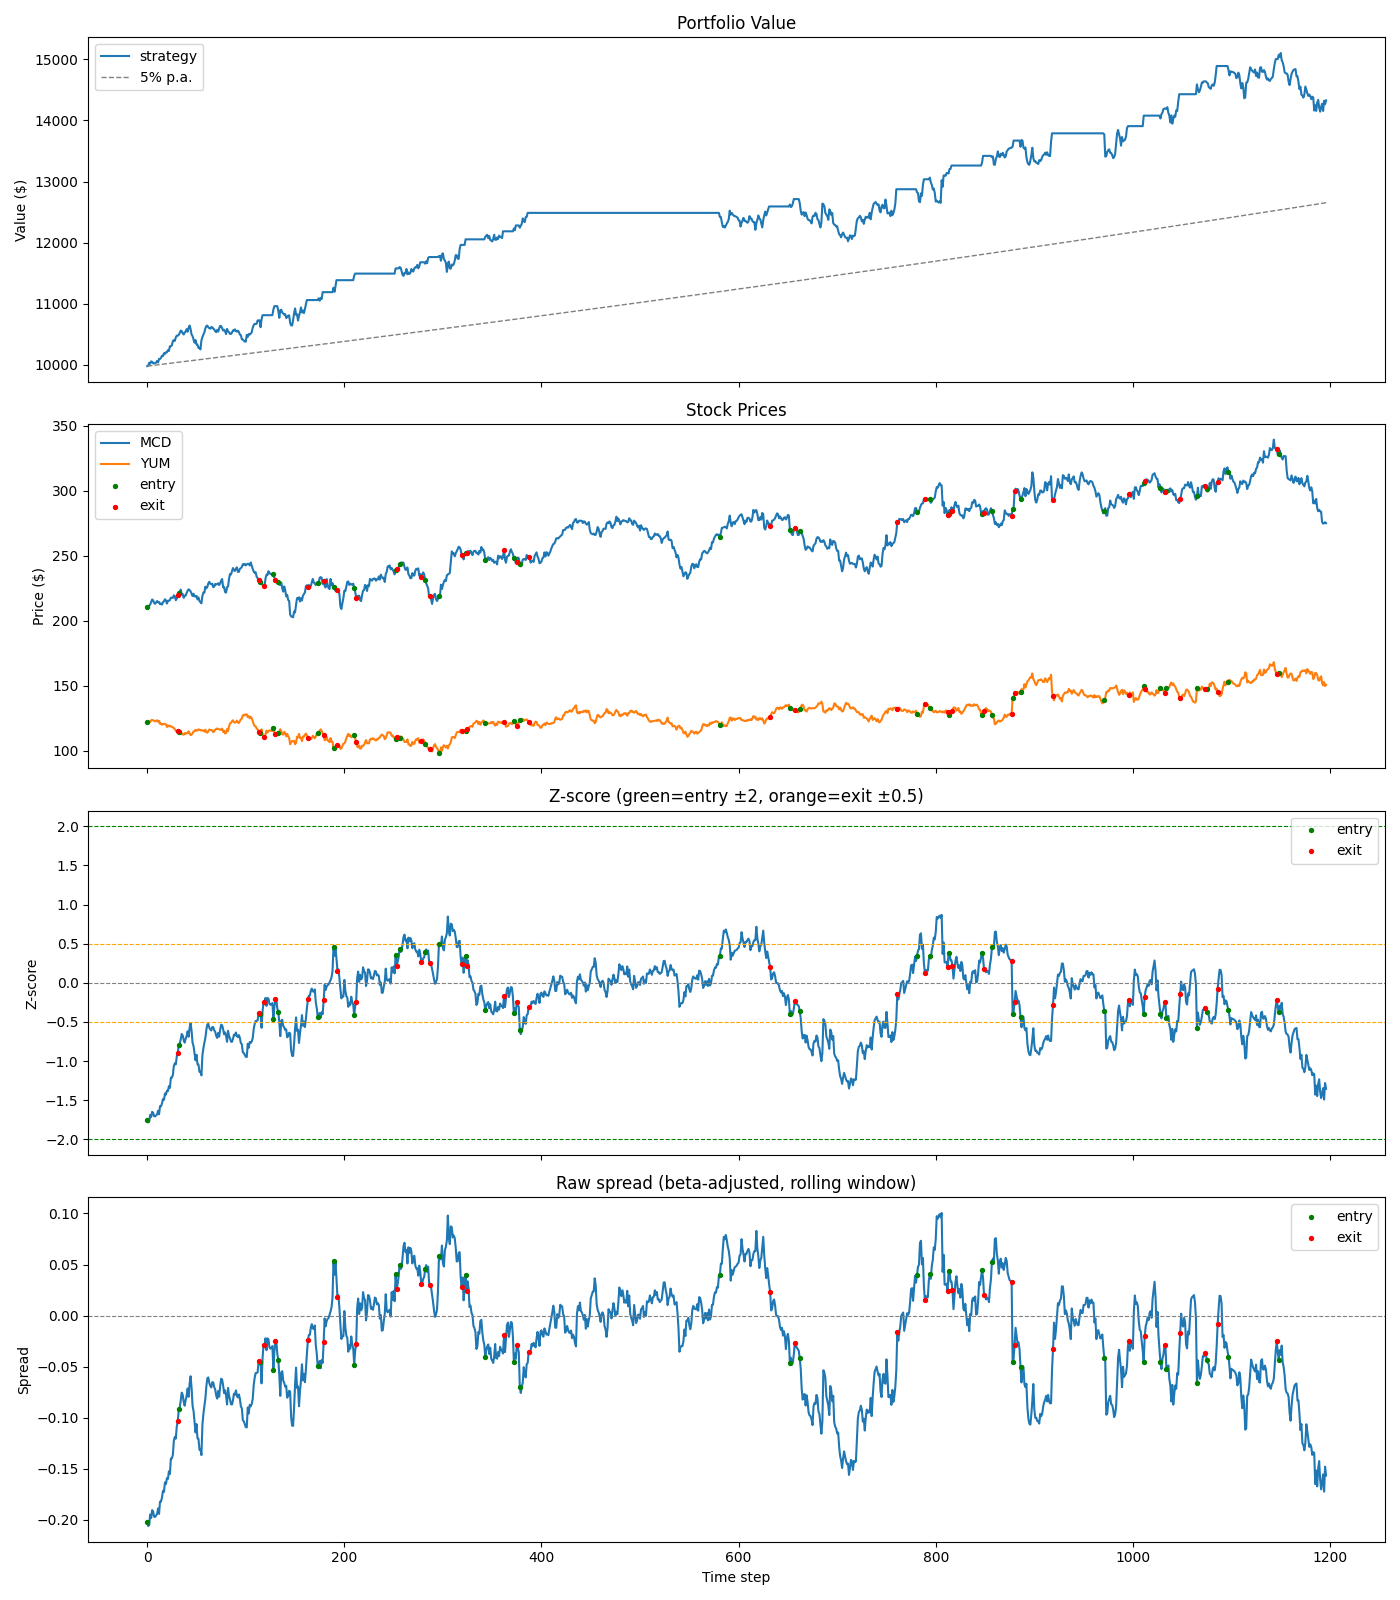

--- Z-score baseline (real Q4 test) ---


/home/tudor/TUDelft/Y3/RP/rl_for_pairs_trading/project/runner_books/../runner.py:97: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend()
/home/tudor/TUDelft/Y3/RP/rl_for_pairs_trading/project/runner_books/../runner.py:108: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[3].legend()


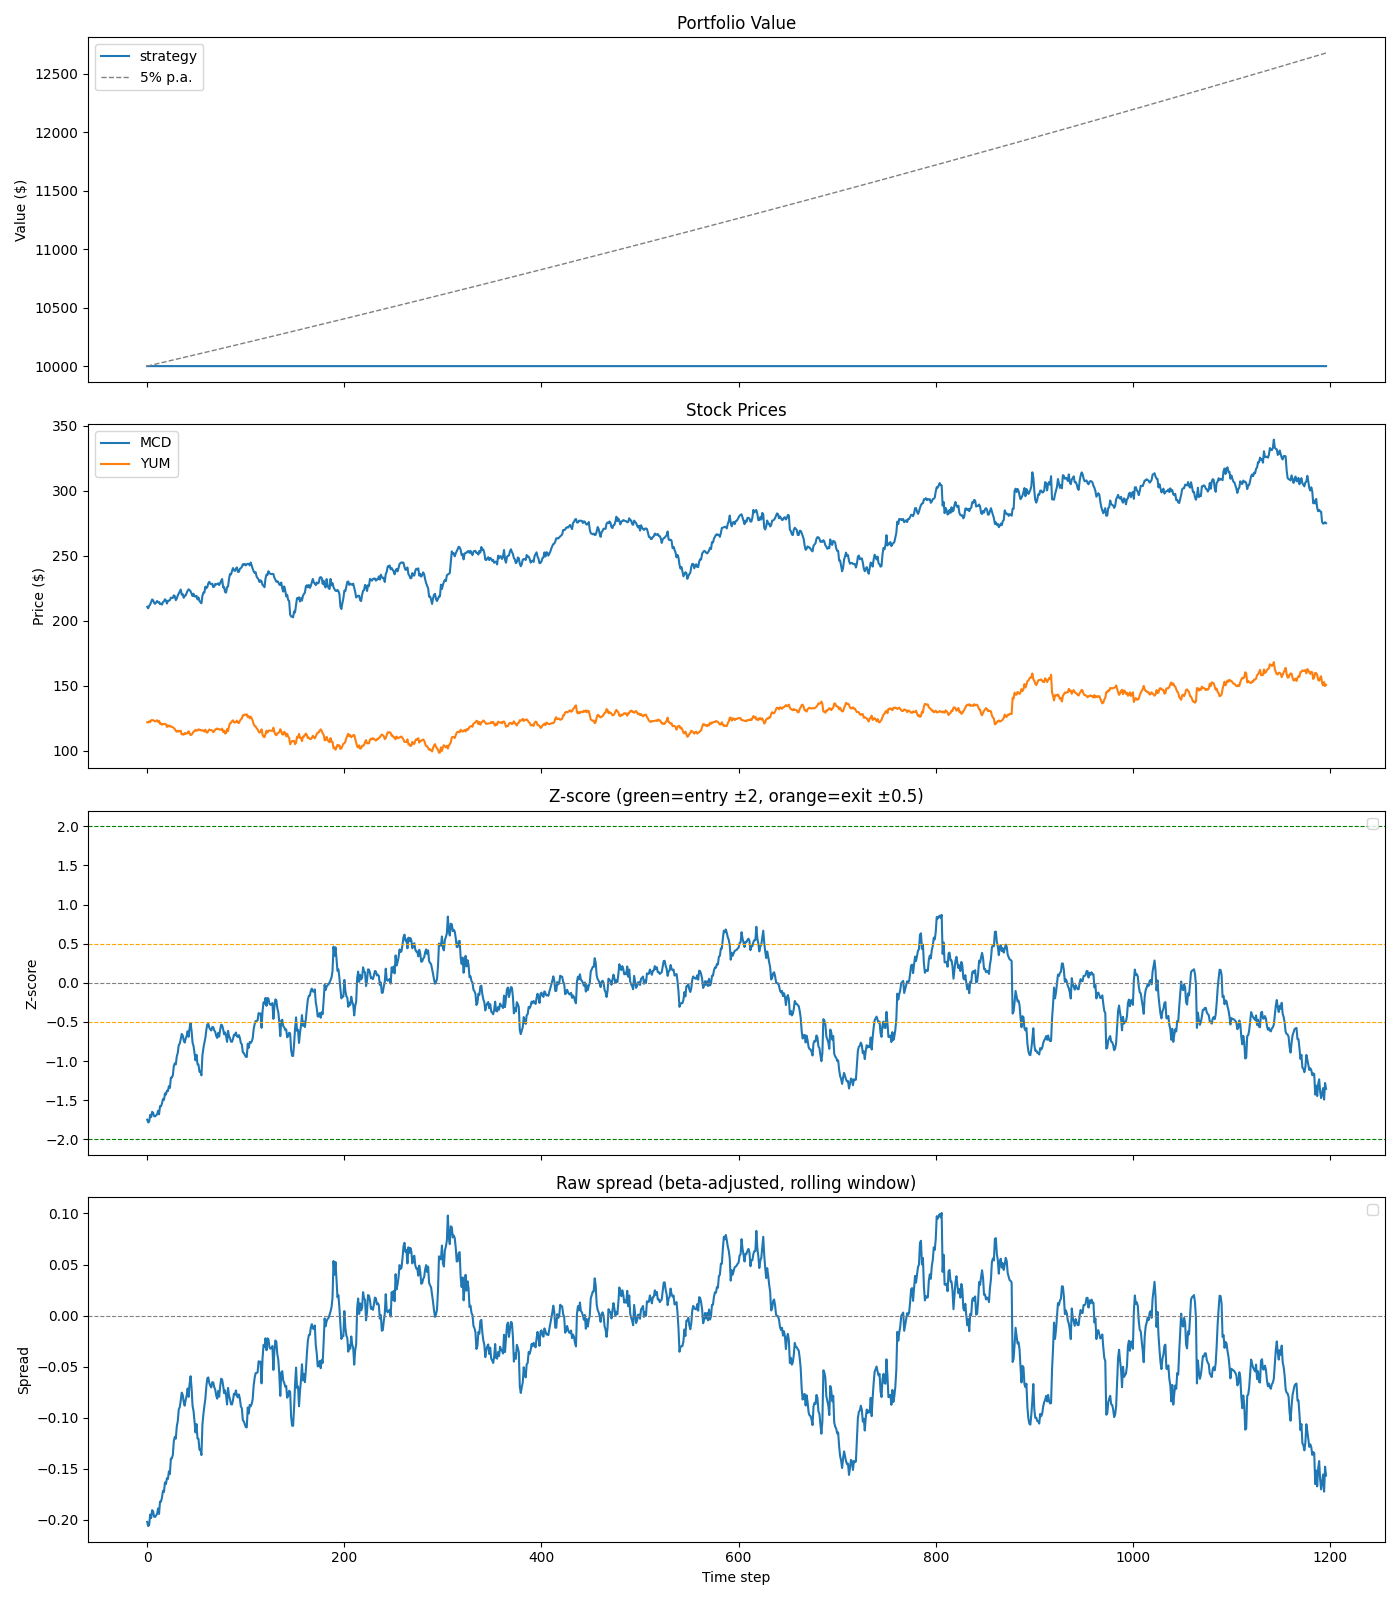

In [3]:
from static_thresh_base import ZScoreBaseline
from runner import run_strategy, plot_strategy

class SB3Agent:
    def __init__(self, model):
        self.model = model

    def predict(self, obs):
        flat = np.array([
            float(obs["position"]),
            abs(float(obs["spread_z_score"][0])),
            abs(float(obs["entry_z_score"][0])),
            abs(float(obs["spread"][0])),
            abs(float(obs["entry_spread"][0])),
            float(obs["macd"][0]),
            float(obs["macd_signal"][0]),
            float(obs["macd_hist"][0]),
        ], dtype=np.float32)
        action, _ = self.model.predict(flat, deterministic=True)
        return int(action)

env_kwargs = dict(fixed_beta=beta, spread_intercept=intercept, fixed_std=fixed_std)

q4_data = data.slice(q4)
results_dqn_q4 = run_strategy(Market(q4_data, **env_kwargs), SB3Agent(model))
print("--- DQN v3 + MACD (real Q4 test) ---")
plot_strategy(results_dqn_q4)

results_base_q4 = run_strategy(Market(q4_data, **env_kwargs), ZScoreBaseline(entry_threshold=2.0, exit_threshold=0.5))
print("--- Z-score baseline (real Q4 test) ---")
plot_strategy(results_base_q4)

--- DQN v3 + MACD on synthetic series 0 ---


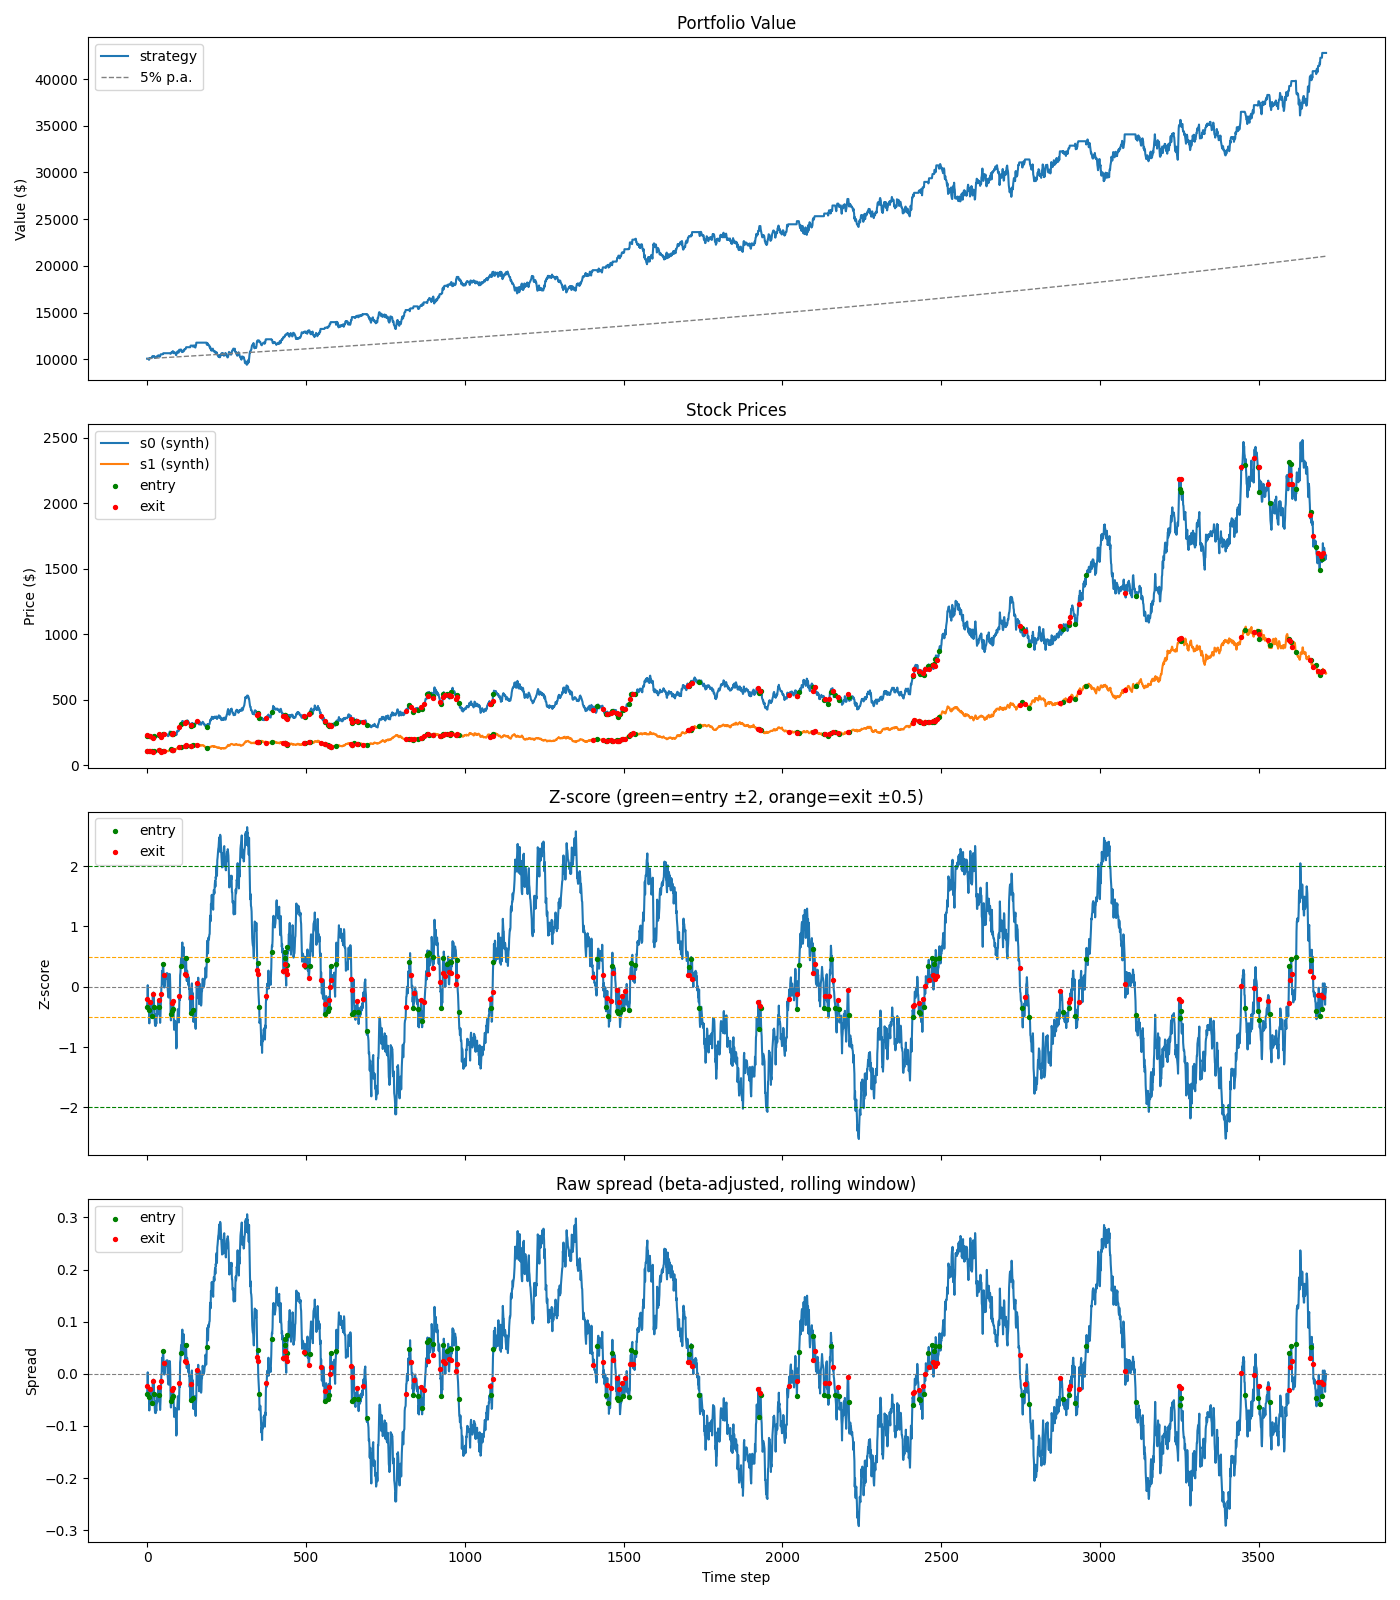

--- Z-score baseline on synthetic series 0 ---


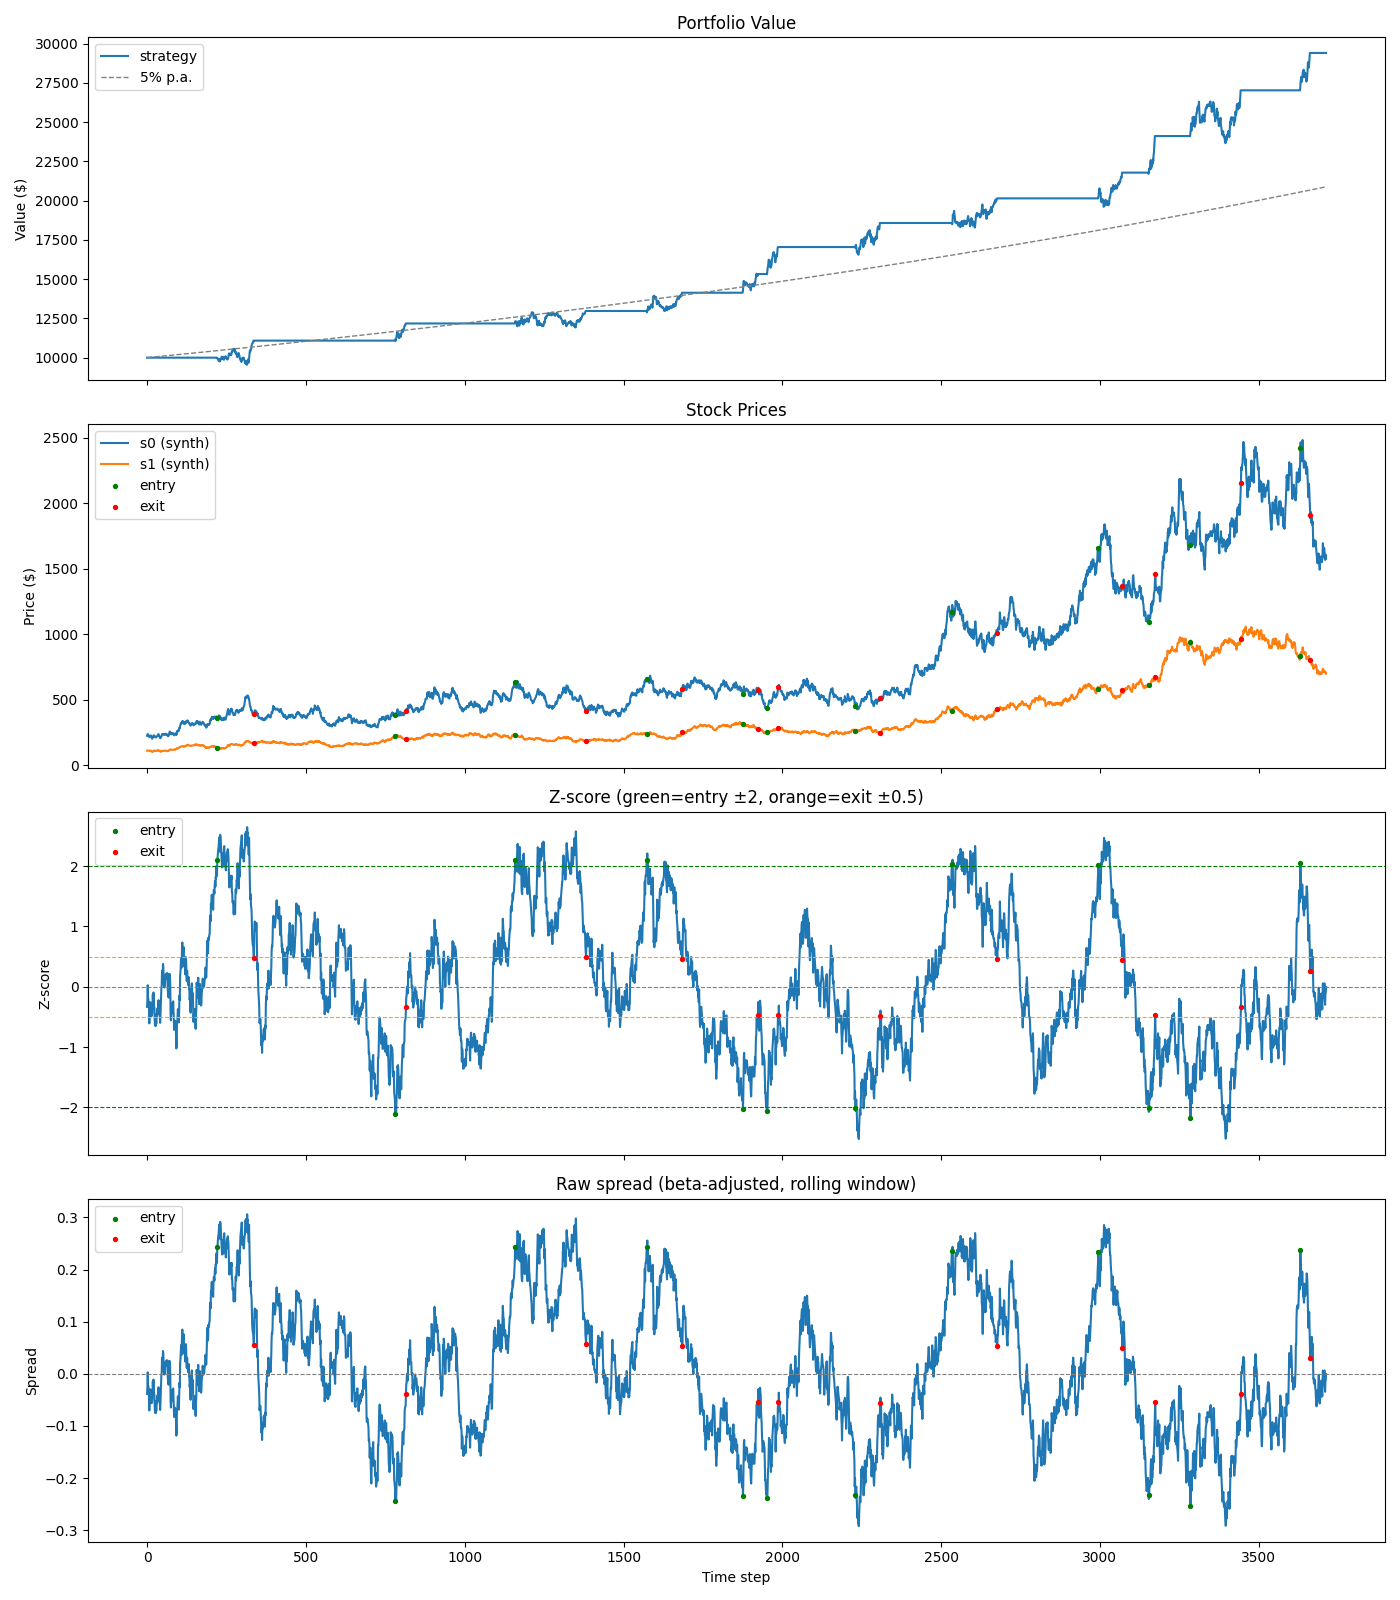

In [4]:
# DQN v3 + MACD on a single synthetic series (series 0)
synth_pair = object.__new__(PairData)
synth_pair.s = pairs[0]
synth_pair.labels = ["s0 (synth)", "s1 (synth)"]
synth_pair.timestamps = np.arange(pairs.shape[2])

results_dqn_synth = run_strategy(Market(synth_pair, **env_kwargs), SB3Agent(model))
print("--- DQN v3 + MACD on synthetic series 0 ---")
plot_strategy(results_dqn_synth)

results_base_synth = run_strategy(Market(synth_pair, **env_kwargs), ZScoreBaseline(entry_threshold=2.0, exit_threshold=0.5))
print("--- Z-score baseline on synthetic series 0 ---")
plot_strategy(results_base_synth)

AAPL/MSFT  β=1.0266  intercept=-0.8570  std=0.1262
Test period: 3774–5032  (1258 steps)
--- DQN v3 on AAPL/MSFT Q4 (zero-shot) ---


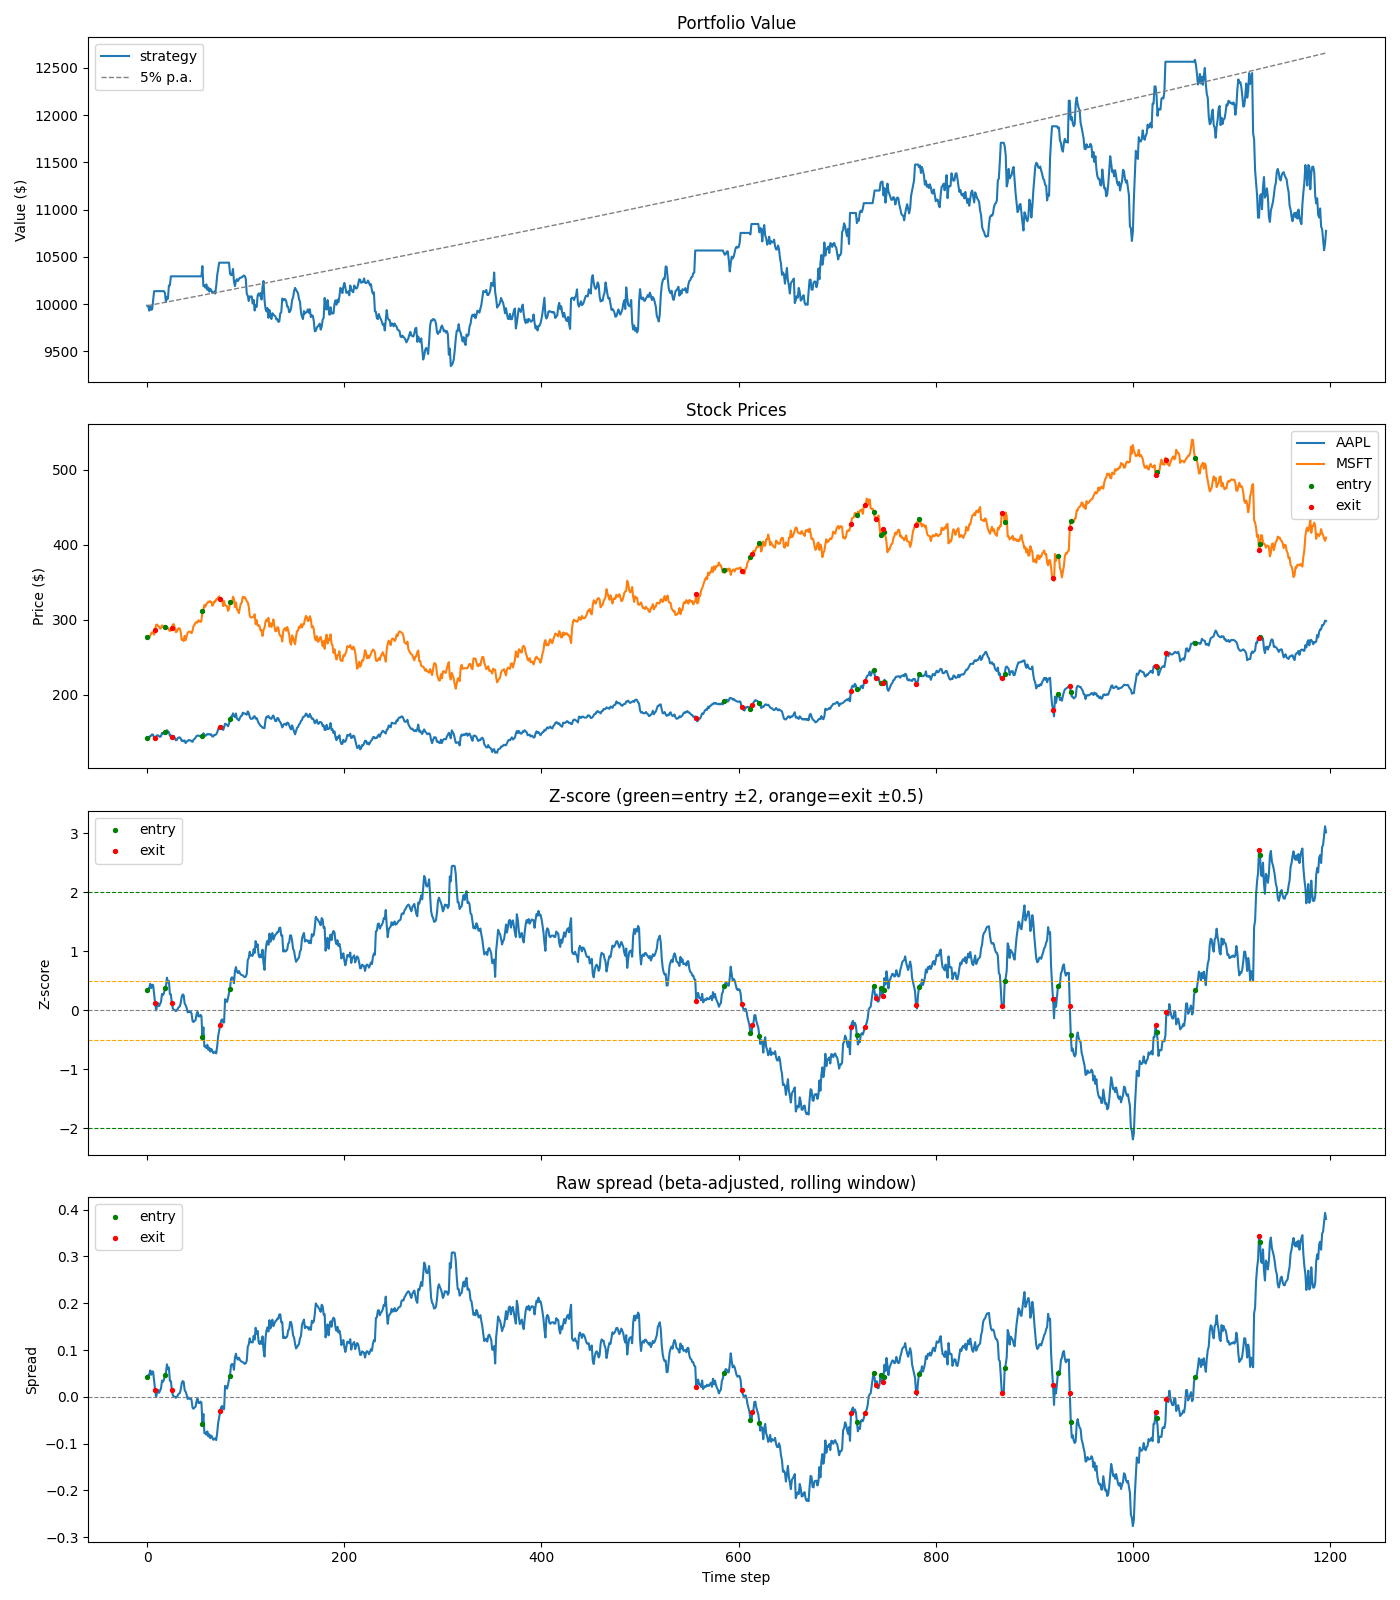

--- Z-score baseline on AAPL/MSFT Q4 ---


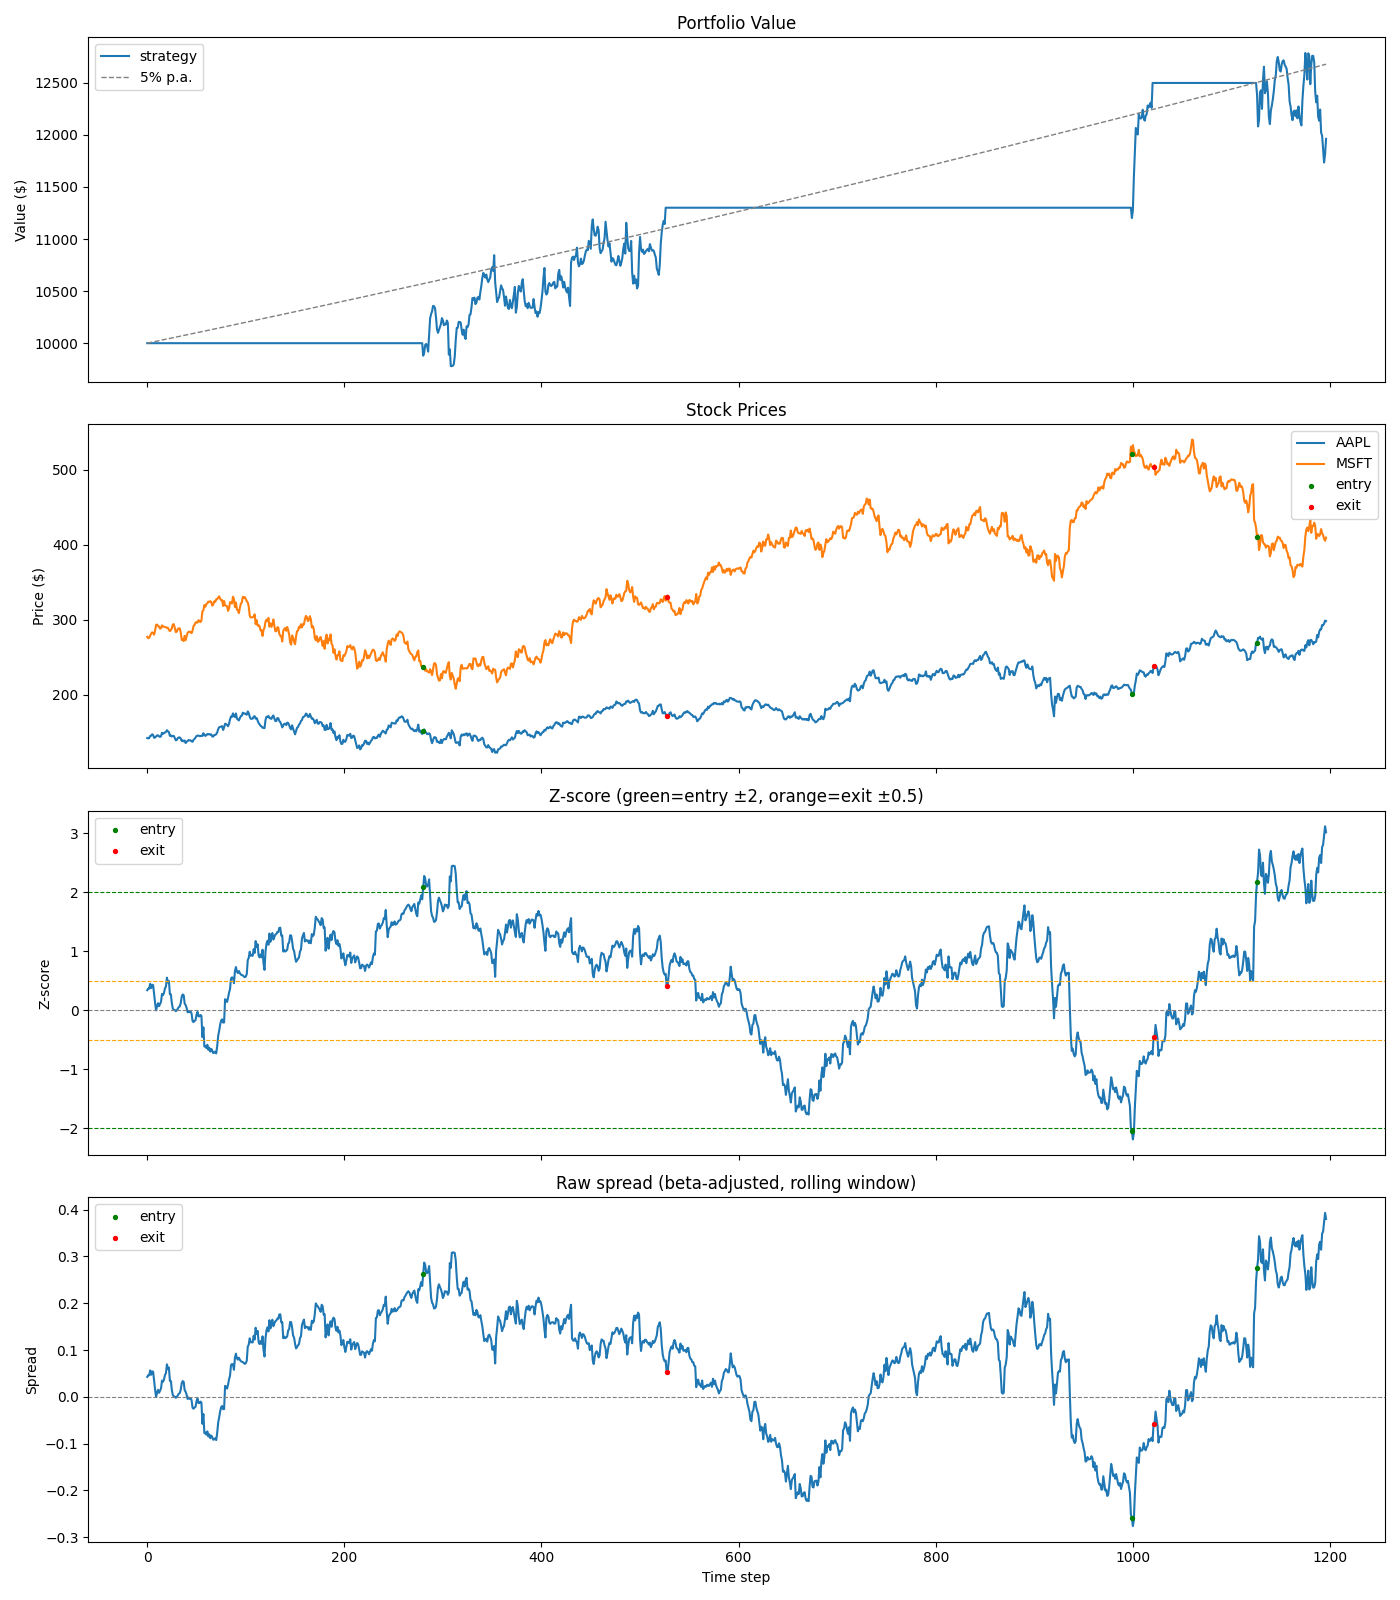

In [6]:
# Zero-shot generalization: run trained MCD/YUM model on AAPL/MSFT (no retraining)
aapl_msft = PairData("../../data/real_pair_AAPL_MSFT.csv")
n_am = len(aapl_msft)
q2_am = n_am // 2
q3_am = 3 * n_am // 4

jres_am      = coint_johansen(np.log(aapl_msft.s[:, q2_am:q3_am]).T, det_order=0, k_ar_diff=1)
cv_am        = jres_am.evec[:, 0]
beta_am      = -cv_am[1] / cv_am[0]
intercept_am = float((np.log(aapl_msft.s[0, q2_am:q3_am]) - beta_am * np.log(aapl_msft.s[1, q2_am:q3_am])).mean())
spread_am    = np.log(aapl_msft.s[0, q2_am:q3_am]) - beta_am * np.log(aapl_msft.s[1, q2_am:q3_am]) - intercept_am
fixed_std_am = float(spread_am.std())

print(f"AAPL/MSFT  β={beta_am:.4f}  intercept={intercept_am:.4f}  std={fixed_std_am:.4f}")
print(f"Test period: {q3_am}–{n_am}  ({n_am - q3_am} steps)")

env_kwargs_am = dict(fixed_beta=beta_am, spread_intercept=intercept_am, fixed_std=fixed_std_am)

q4_am_data = aapl_msft.slice(q3_am)
results_dqn_am = run_strategy(Market(q4_am_data, **env_kwargs_am), SB3Agent(model))
print("--- DQN v3 on AAPL/MSFT Q4 (zero-shot) ---")
plot_strategy(results_dqn_am)

results_base_am = run_strategy(Market(q4_am_data, **env_kwargs_am), ZScoreBaseline(entry_threshold=2.0, exit_threshold=0.5))
print("--- Z-score baseline on AAPL/MSFT Q4 ---")
plot_strategy(results_base_am)